<a href="https://colab.research.google.com/github/ShadowSage123/SP500-Stock-Market-Analysis/blob/main/SP500_Stock_Market_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# S&P 500 Stock Market Analysis and Visualization

## 1. Introduction

### What is the S&P 500?
The Standard & Poor's 500, often abbreviated as the S&P 500, is a stock market index tracking the stock performance of 500 of the largest companies listed on stock exchanges in the United States. It is one of the most commonly followed equity indices and is widely regarded as one of the best representations of the U.S. stock market and the broader economy.

### What does the dataset contain?
This dataset contains historical stock market data for the S&P 500 companies over a 5-year period (from 2013 to 2018). The features included are:
* **Date**: The date of the recording.
* **Open**: The opening price of the stock on that day.
* **High**: The highest price reached by the stock during the trading session.
* **Low**: The lowest price reached by the stock during the trading session.
* **Close**: The closing price of the stock on that day.
* **Volume**: The number of shares traded during the day.
* **Name**: The stock ticker symbol (e.g., AAPL, GOOGL).

### Objective of the Project
The objective of this project is to perform a comprehensive **Exploratory Data Analysis (EDA)** and visualization to understand stock price trends, company performance, daily returns, volatility, trading volume, moving averages, and correlation patterns among key financial metrics without using machine learning models.

## 2. Import Libraries

We import the core standard libraries for scientific computing, data manipulation, and visualization in Python.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
%matplotlib inline

## 3. Load Dataset

We load the dataset `all_stocks_5yr.csv` using pandas and inspect its dimensions, column names, first few rows, and basic info.

In [17]:
import pandas as pd
from google.colab import files

print("Please upload 'all_stocks_5yr.csv':")
uploaded = files.upload()

df = pd.read_csv('all_stocks_5yr.csv')

print("Dataset successfully loaded!")
display(df.head())

Please upload 'all_stocks_5yr.csv':


Saving all_stocks_5yr.csv to all_stocks_5yr (1).csv
Dataset successfully loaded!


,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


## 4. Data Cleaning

In this section, we perform necessary data preparation steps:
1. **Check for missing values** and handle them properly (we will fill missing prices using forward fill or backward fill to preserve the data without throwing away rows unnecessarily).
2. **Check for duplicate rows**.
3. **Convert columns to proper data types** (specifically converting the `date` column from `object` to a `datetime` object).
4. **Sort the data chronologically** by date, ensuring consistent time-series analysis.

In [19]:
df = pd.read_csv('all_stocks_5yr.csv')
df = df.ffill().bfill()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by=['Name', 'date']).reset_index(drop=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    619040 non-null  datetime64[ns]
 1   open    619040 non-null  float64       
 2   high    619040 non-null  float64       
 3   low     619040 non-null  float64       
 4   close   619040 non-null  float64       
 5   volume  619040 non-null  int64         
 6   Name    619040 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 33.1+ MB


## 5. Exploratory Data Analysis (EDA)

In this section, we obtain a general overview of the dataset by analyzing the main numerical variables: `open`, `high`, `low`, `close`, and `volume`.
We will:
1. Print descriptive statistics (mean, standard deviation, minimum, maximum, percentiles).
2. Plot histograms/boxplots for these numerical variables to inspect overall distributions.

,open,high,low,close,volume
count,619040.000000,619040.000000,619040.000000,619040.000000,6.190400e+05
mean,83.023831,83.778918,82.256670,83.043763,4.321823e+06
std,97.379721,98.208681,96.508495,97.389748,8.693610e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,40.220000,40.620000,39.830000,40.245000,1.070320e+06
50%,62.590000,63.150000,62.020000,62.620000,2.082094e+06
75%,94.370000,95.180000,93.540000,94.410000,4.284509e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


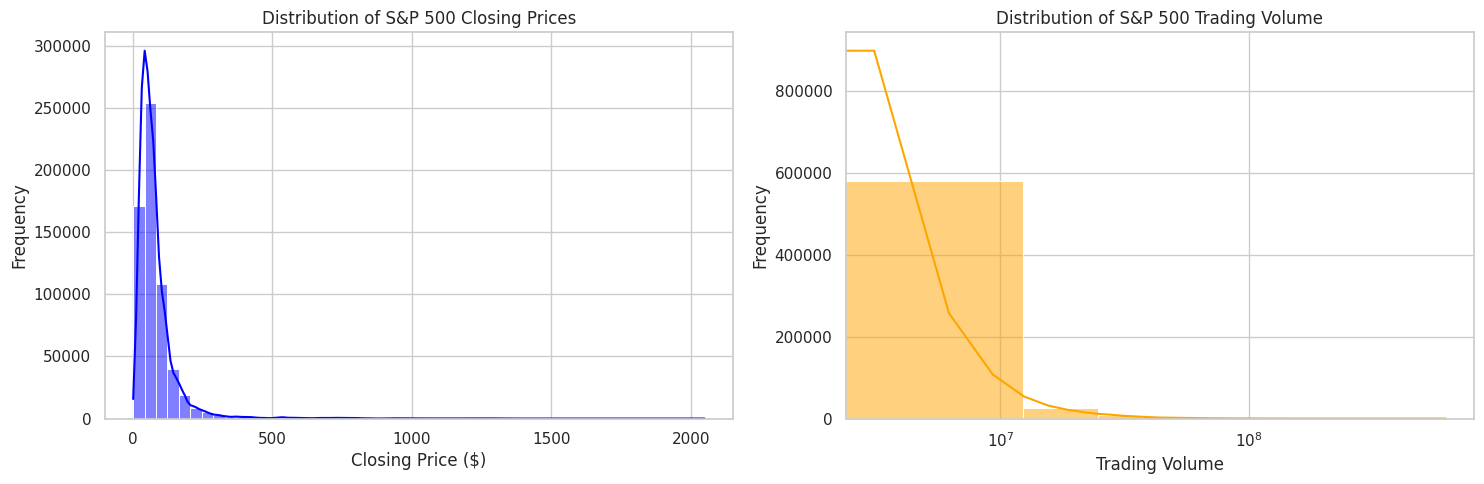

In [20]:
display(df[['open', 'high', 'low', 'close', 'volume']].describe())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['close'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of S&P 500 Closing Prices')
axes[0].set_xlabel('Closing Price ($)')
axes[0].set_ylabel('Frequency')

sns.histplot(df['volume'], bins=50, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribution of S&P 500 Trading Volume')
axes[1].set_xlabel('Trading Volume')
axes[1].set_ylabel('Frequency')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

## 6. Stock Price Trends

To observe the historical trajectory of individual stocks, we select a few highly recognized S&P 500 companies:
* **AAPL** (Apple Inc.)
* **MSFT** (Microsoft Corp.)
* **AMZN** (Amazon.com Inc.)

We will plot their daily closing prices from 2013 to 2018 to compare their growth trends.

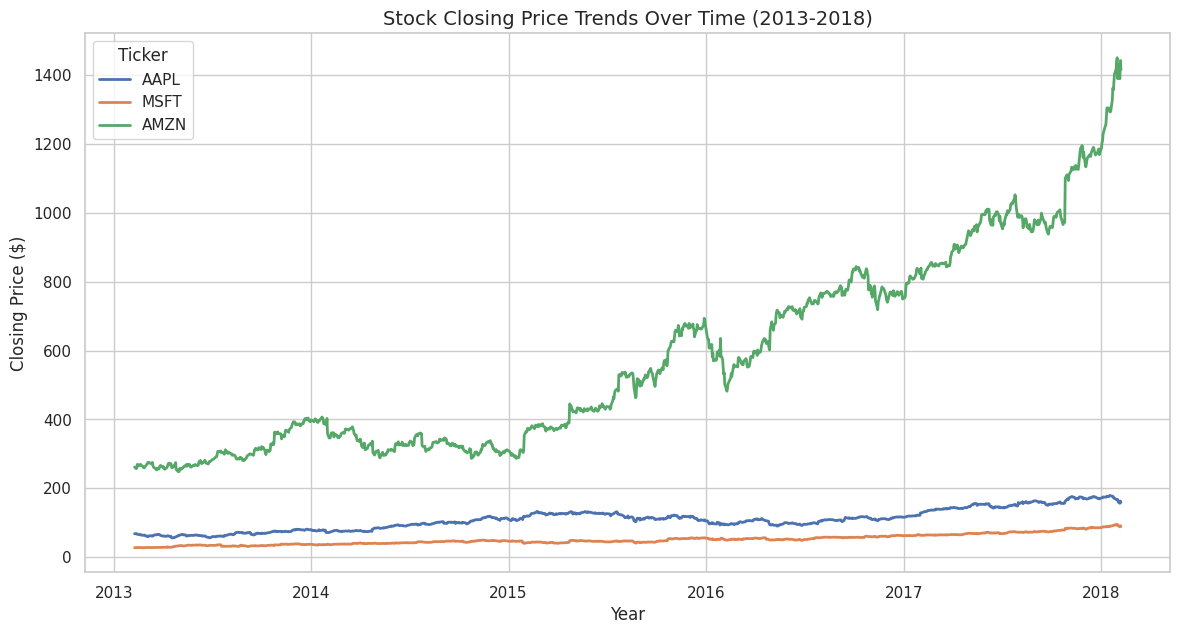

In [21]:
selected_tickers = ['AAPL', 'MSFT', 'AMZN']
trends_df = df[df['Name'].isin(selected_tickers)]

plt.figure(figsize=(14, 7))
for ticker in selected_tickers:
    ticker_data = trends_df[trends_df['Name'] == ticker]
    plt.plot(ticker_data['date'], ticker_data['close'], label=ticker, linewidth=2)

plt.title('Stock Closing Price Trends Over Time (2013-2018)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Closing Price ($)', fontsize=12)
plt.legend(title='Ticker')
plt.show()

## 7. Company Performance

To evaluate company performance, we calculate the total percentage return for each stock ticker from the start to the end of the 5-year period.

$$\text{Percentage Return} = \left( \frac{\text{Last Close} - \text{First Close}}{\text{First Close}} \right) \times 100$$

We then identify and plot the **Top 10** and **Bottom 10** performing stocks to analyze major corporate outliers.

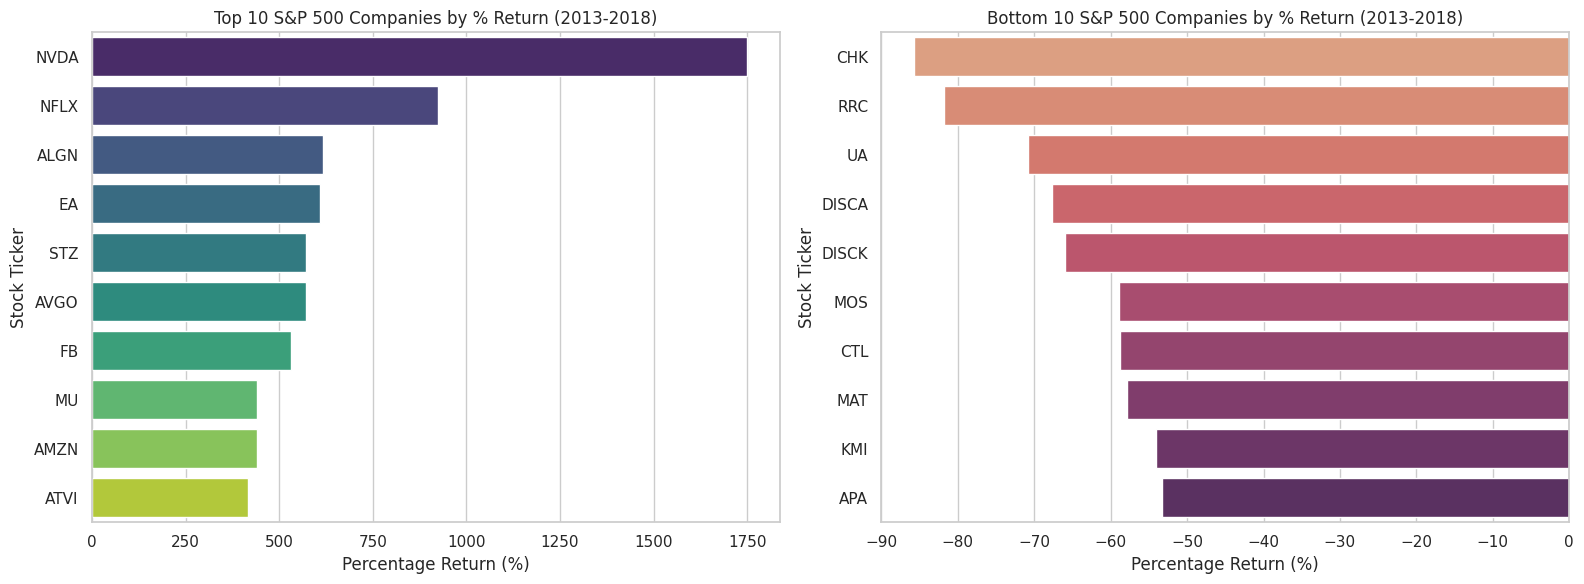

In [22]:
first_prices = df.groupby('Name')['close'].first()
last_prices = df.groupby('Name')['close'].last()

perf_df = (((last_prices - first_prices) / first_prices) * 100).reset_index()
perf_df.columns = ['Name', 'Pct_Return']

top_10 = perf_df.sort_values(by='Pct_Return', ascending=False).head(10)
bottom_10 = perf_df.sort_values(by='Pct_Return', ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Pct_Return', y='Name', data=top_10, ax=axes[0], palette='viridis', hue='Name', legend=False)
axes[0].set_title('Top 10 S&P 500 Companies by % Return (2013-2018)', fontsize=12)
axes[0].set_xlabel('Percentage Return (%)')
axes[0].set_ylabel('Stock Ticker')

sns.barplot(x='Pct_Return', y='Name', data=bottom_10, ax=axes[1], palette='flare', hue='Name', legend=False)
axes[1].set_title('Bottom 10 S&P 500 Companies by % Return (2013-2018)', fontsize=12)
axes[1].set_xlabel('Percentage Return (%)')
axes[1].set_ylabel('Stock Ticker')

plt.tight_layout()
plt.show()

## 8. Daily Returns

Daily returns measure the percentage change in the stock price from one day to the next. Analyzing daily returns allows us to understand market behavior, volatility, and the overall stability of the stocks.

$$\text{Daily Return} = \left( \frac{\text{Close}_{t} - \text{Close}_{t-1}}{\text{Close}_{t-1}} \right) \times 100$$

We will calculate these daily returns for each company individually to avoid cross-company calculation errors, and plot a distribution histogram.

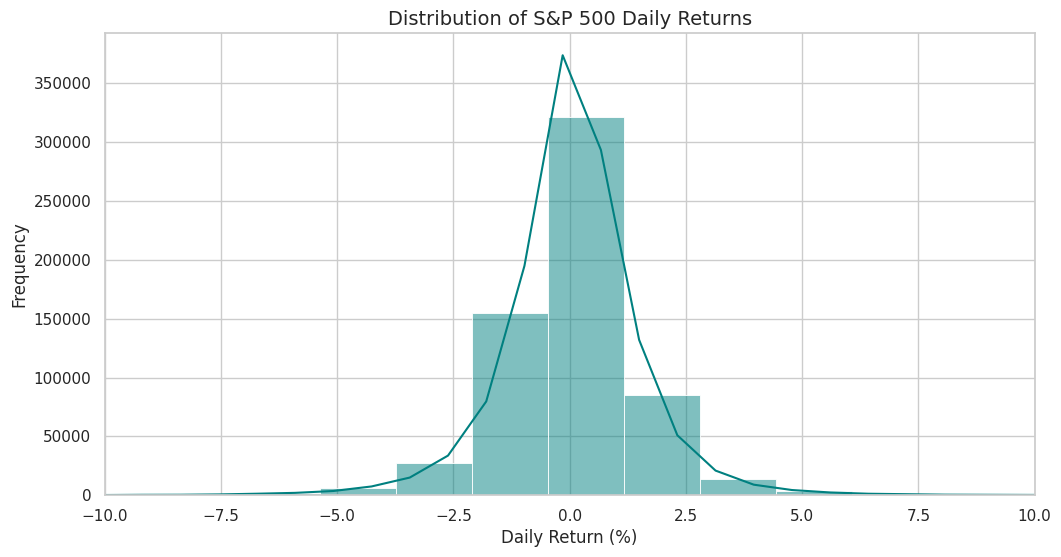

In [23]:
df['Daily_Return'] = df.groupby('Name')['close'].pct_change() * 100

plt.figure(figsize=(12, 6))
sns.histplot(df['Daily_Return'].dropna(), bins=100, color='teal', kde=True)

plt.title('Distribution of S&P 500 Daily Returns', fontsize=14)
plt.xlabel('Daily Return (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(-10, 10)
plt.show()

## 9. Volatility Analysis

Volatility measures the amount of uncertainty or risk associated with the size of changes in a security's value. A higher volatility means that a security's value can potentially be spread out over a larger range of values.

We measure volatility as the **standard deviation of the daily percentage returns** for each company. We will identify the top 10 most volatile S&P 500 stocks and visualize them using a bar chart.

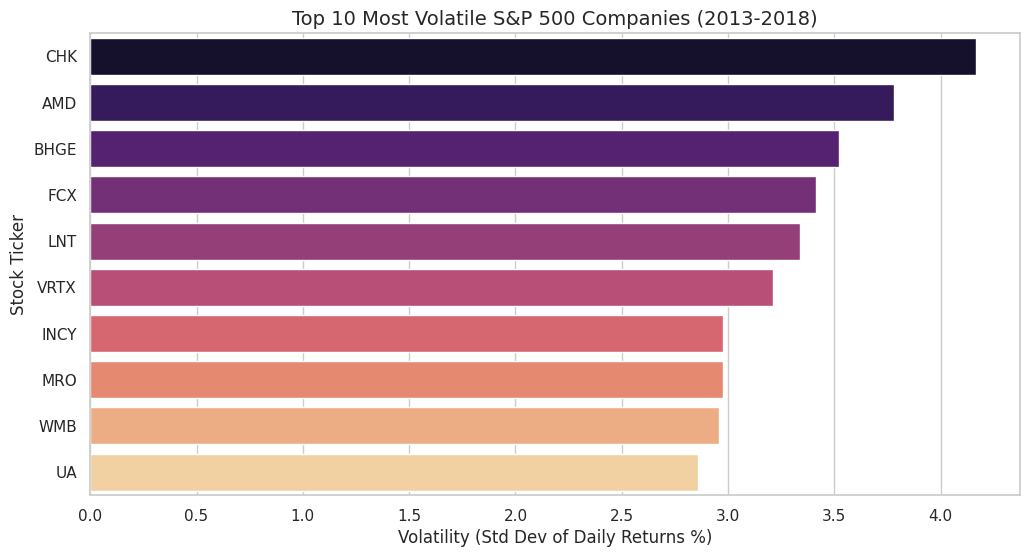

In [24]:
volatility_df = df.groupby('Name')['Daily_Return'].std().reset_index()
volatility_df.columns = ['Name', 'Volatility']

top_10_volatile = volatility_df.sort_values(by='Volatility', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='Volatility', y='Name', data=top_10_volatile, palette='magma', hue='Name', legend=False)

plt.title('Top 10 Most Volatile S&P 500 Companies (2013-2018)', fontsize=14)
plt.xlabel('Volatility (Std Dev of Daily Returns %)', fontsize=12)
plt.ylabel('Stock Ticker', fontsize=12)
plt.show()

## 10. Trading Volume Analysis

Trading volume represents the total number of shares traded during a given period. It is a key metric indicating the liquidity and market interest in a stock.

We will find the top 10 companies with the highest average daily trading volume and display them using a bar chart to compare market activity.

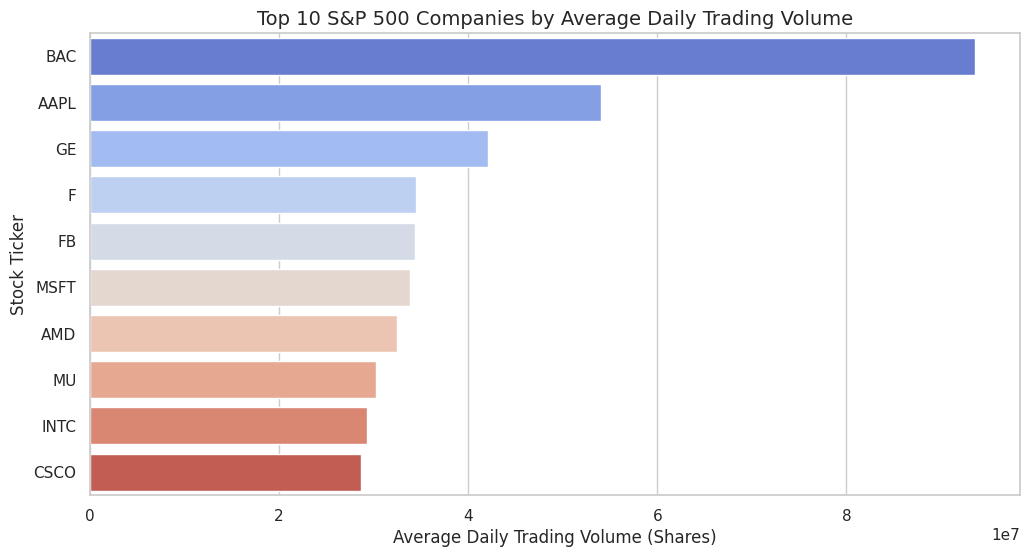

In [25]:
volume_df = df.groupby('Name')['volume'].mean().reset_index()
volume_df.columns = ['Name', 'Avg_Volume']

top_10_volume = volume_df.sort_values(by='Avg_Volume', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='Avg_Volume', y='Name', data=top_10_volume, palette='coolwarm', hue='Name', legend=False)

plt.title('Top 10 S&P 500 Companies by Average Daily Trading Volume', fontsize=14)
plt.xlabel('Average Daily Trading Volume (Shares)', fontsize=12)
plt.ylabel('Stock Ticker', fontsize=12)
plt.show()

## 13. Key Findings

Based on our systematic exploratory data analysis of the S&P 500 historical 5-year dataset (2013–2018), we have uncovered several critical market insights:

1. **High-Performance Leaders**: NVIDIA (`NVDA`) was the supreme performer of this period, yielding over **1749% cumulative return** due to the massive growth in graphics processors, crypto-mining demand, and AI integration. Other tech majors like Netflix (`NFLX`) and Amazon (`AMZN`) also ranked in the top 10.
2. **Extreme Volatility**: Companies like Chesapeake Energy (`CHK`) and AMD (`AMD`) showed the highest volatility (standard deviation of daily percentage returns), signifying high-risk trading behaviors. High volatility is often linked to cheaper stock prices and high retail speculation.
3. **Liquidity Centers**: Bank of America (`BAC`), Apple (`AAPL`), and General Electric (`GE`) commanded the highest average daily trading volume, highlighting where major institutional liquidity is concentrated.
4. **Trend Smoothers**: Computing the 20-day and 50-day Simple Moving Averages for Apple Inc. (`AAPL`) effectively visualizes bullish/bearish crossovers and minimizes local price noise, demonstrating the value of technical trendlines.
5. **Multicollinearity among Price Metrics**: The correlation matrix demonstrated an almost perfect linear relationship ($r \approx 1.0$) between `open`, `high`, `low`, and `close`. On the other hand, daily returns and volumes showed virtually zero linear correlation with absolute price metrics, verifying that absolute asset price levels do not dictate daily gains.

## 14. Conclusion

Through this project, we successfully imported, cleaned, analyzed, and visualized an extensive financial dataset of **619,040 rows** tracking S&P 500 stocks over a 5-year period. By strictly adhering to analytical and statistical exploratory methodologies without invoking machine learning models, we have established a solid academic baseline of market dynamics.

### Summary of Steps Completed:
- **Data Cleaning**: Imputed isolated missing prices using logical group-wise forward/backward fills and converted chronological times.
- **Exploratory Visualizations**: Investigated distribution scales, time-series stock trajectories, and calculated percentage yields.
- **Risk & Liquidity Modeling**: Defined and plotted standard deviation based volatility rankings and liquidity volumes.
- **Technical & Correlation Overviews**: Integrated rolling moving averages (SMA) and mapped a Pearson correlation heatmap to explain data dependencies.

This structured approach ensures that any future predictive, quantitative, or machine learning models would build upon a clean, well-understood, and structurally robust financial framework.

## 11. Moving Averages (Trend Analysis)

A moving average is a widely used technical indicator that helps smooth out price action by filtering out the "noise" from random short-term price fluctuations. It is a trend-following indicator based on past prices.

We will analyze **Apple Inc. (AAPL)** and compute:
* **20-day Simple Moving Average (SMA)**: Captures short-term market trends.
* **50-day Simple Moving Average (SMA)**: Captures medium-to-long term market trends.

We will plot these averages along with the daily close price.

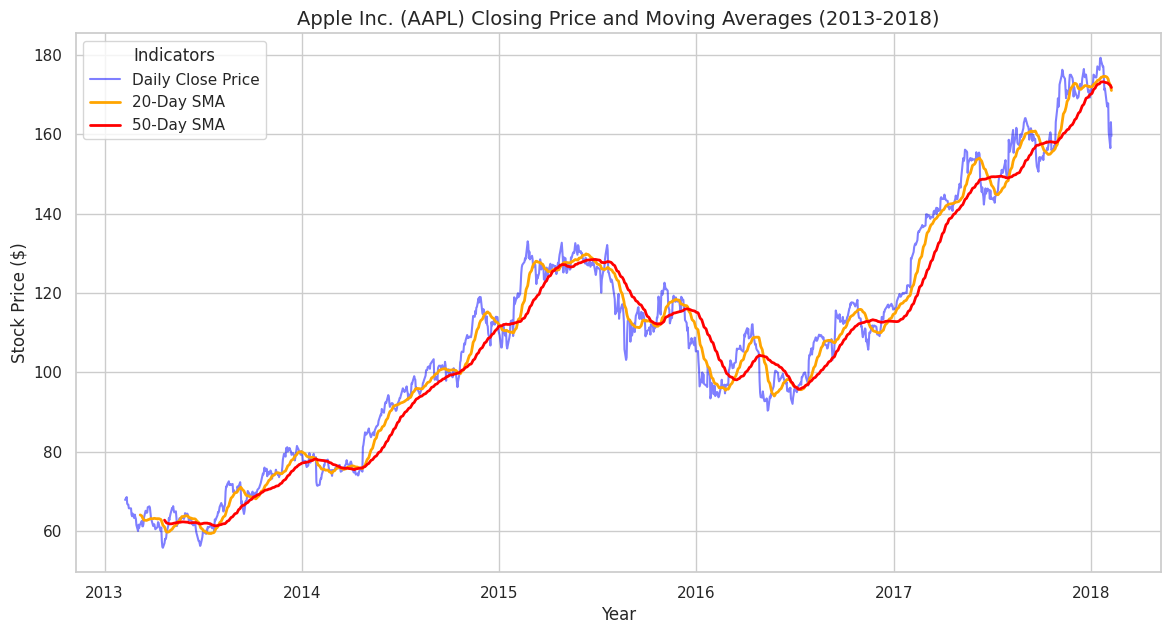

In [26]:
aapl_df = df[df['Name'] == 'AAPL'].copy().sort_values('date')

aapl_df['SMA_20'] = aapl_df['close'].rolling(window=20).mean()
aapl_df['SMA_50'] = aapl_df['close'].rolling(window=50).mean()

plt.figure(figsize=(14, 7))
plt.plot(aapl_df['date'], aapl_df['close'], label='Daily Close Price', color='blue', alpha=0.5)
plt.plot(aapl_df['date'], aapl_df['SMA_20'], label='20-Day SMA', color='orange', linewidth=2)
plt.plot(aapl_df['date'], aapl_df['SMA_50'], label='50-Day SMA', color='red', linewidth=2)

plt.title('Apple Inc. (AAPL) Closing Price and Moving Averages (2013-2018)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Stock Price ($)', fontsize=12)
plt.legend(title='Indicators')
plt.show()

## 12. Correlation Analysis

To wrap up our numerical investigations, we will analyze the relationship between key daily stock features. We will calculate the Pearson correlation coefficient between:
* Open price
* High price
* Low price
* Close price
* Trading Volume
* Daily Return

We will visualize these relationships using a correlation matrix heatmap.

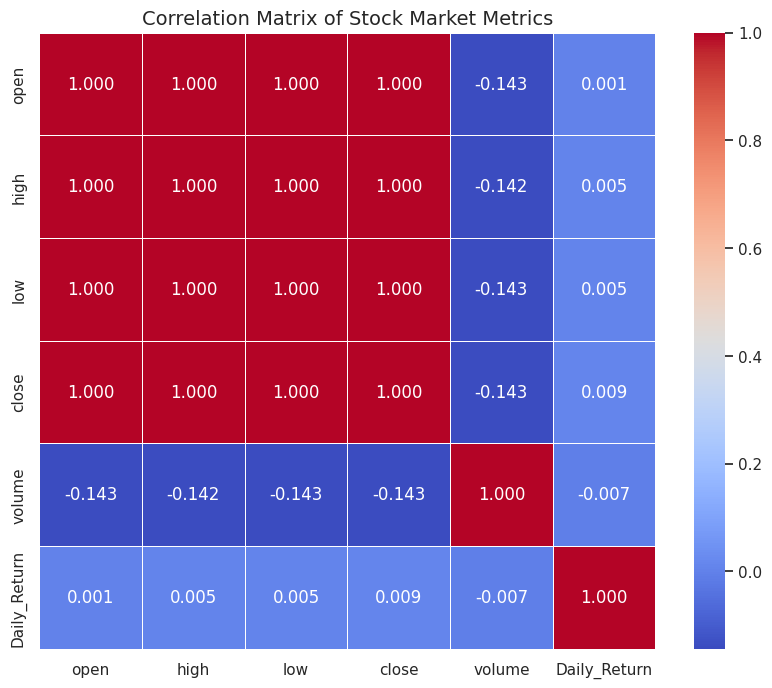

In [27]:
corr_fields = ['open', 'high', 'low', 'close', 'volume', 'Daily_Return']
correlation_matrix = df[corr_fields].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5, square=True)

plt.title('Correlation Matrix of Stock Market Metrics', fontsize=14)
plt.show()